In [ ]:
# Harley Lainez-Murillo
# DTSC 2301-001
#02/20/2026
#Project 1: Defining a Data Science Problem & Understanding Data
#Premier League Champion Blueprint:
#Goal/Objective: To find what specific metrics are most important for predicting a team's success in the Premier League.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
#BBC Updated and Current Premier League Table - 02/23/2026
url = "https://www.bbc.co.uk/sport/football/premier-league/table"

df = pd.read_html(url)[0]

In [4]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Team                              20 non-null     object
 1   Played                            20 non-null     int64 
 2   Won                               20 non-null     int64 
 3   Drawn                             20 non-null     int64 
 4   Lost                              20 non-null     int64 
 5   Goals For                         20 non-null     int64 
 6   Goals Against                     20 non-null     int64 
 7   Goal Difference                   20 non-null     int64 
 8   Points                            20 non-null     int64 
 9   Form, Last 6 games, Oldest first  20 non-null     object
dtypes: int64(8), object(2)
memory usage: 1.7+ KB


In [5]:
df.head()

,Team,Played,Won,Drawn,Lost,Goals For,Goals Against,Goal Difference,Points,"Form, Last 6 games, Oldest first"
0,1Arsenal,28,18,7,3,56,21,35,61,LResult LossWResult WinWResult WinDResult Draw...
1,2Manchester City,27,17,5,5,56,25,31,56,LResult LossWResult WinDResult DrawWResult Win...
2,3Aston Villa,27,15,6,6,38,28,10,51,LResult LossWResult WinLResult LossDResult Dra...
3,4Manchester United,27,13,9,5,48,37,11,48,WResult WinWResult WinWResult WinWResult WinDR...
4,5Chelsea,27,12,9,6,48,31,17,45,WResult WinWResult WinWResult WinWResult WinDR...


In [ ]:
#Renaming the 'Form' column a shorter one.
df.rename(columns={'Form, Last 6 games, Oldest first':'Form', 'Goals For': 'Goals Forward'} , inplace=True) 
#without inplace=True allows the change to be made directly to the DataFrame without needing to assign it back to df.

In [ ]:

df.columns #indexes the columns of the DataFrame to check the new column names after renaming.

Index(['Team', 'Played', 'Won', 'Drawn', 'Lost', 'Goals Forward',
       'Goals Against', 'Goal Difference', 'Points', 'Form'],
      dtype='object')

In [ ]:
df['Form'] #Accesses the 'Form' column to check the values after renaming.

0     LResult LossWResult WinWResult WinDResult Draw...
1     LResult LossWResult WinDResult DrawWResult Win...
2     LResult LossWResult WinLResult LossDResult Dra...
3     WResult WinWResult WinWResult WinWResult WinDR...
4     WResult WinWResult WinWResult WinWResult WinDR...
5     DResult DrawLResult LossWResult WinLResult Los...
6     LResult LossLResult LossWResult WinWResult Win...
7     DResult DrawWResult WinWResult WinDResult Draw...
8     WResult WinDResult DrawDResult DrawWResult Win...
9     LResult LossWResult WinLResult LossLResult Los...
10    DResult DrawLResult LossLResult LossLResult Lo...
11    WResult WinLResult LossWResult WinLResult Loss...
12    LResult LossLResult LossDResult DrawWResult Wi...
13    DResult DrawLResult LossDResult DrawLResult Lo...
14    WResult WinDResult DrawLResult LossWResult Win...
15    LResult LossDResult DrawDResult DrawLResult Lo...
16    DResult DrawWResult WinDResult DrawLResult Los...
17    WResult WinWResult WinLResult LossWResult 

In [ ]:
#Replaces the worded results with single letters
df['Form'] = df['Form'].str.replace('DResult Draw', 'D') #Replaces 'DResult Draw' with 'D' in the 'Form' column.
df['Form'] = df['Form'].str.replace('WResult Win', 'W') #Replaces 'WResult Win' with 'W' in the 'Form' column.
df['Form'] = df['Form'].str.replace('LResult Loss', 'L') #Replaces 'LResult Loss' with 'L' in the 'Form' column.
display(df['Form']) 
# check
df.head() #First 5 Rows of DataFrame

0     LWWDDW
1     LWDWWW
2     LWLDWD
3     WWWWDW
4     WWWWDD
5     DLWLWW
6     LLWWDL
7     DWWDWD
8     WDDWLL
9     LWLLLW
10    DLLLWL
11    WLWLLL
12    LLDWLW
13    DLDLLW
14    WDLWDD
15    LDDLLL
16    DWDLDL
17    WWLWDD
18    DDLLWD
19    LLLDDL
Name: Form, dtype: object

,Team,Played,Won,Drawn,Lost,Goals Forward,Goals Against,Goal Difference,Points,Form
0,1Arsenal,28,18,7,3,56,21,35,61,LWWDDW
1,2Manchester City,27,17,5,5,56,25,31,56,LWDWWW
2,3Aston Villa,27,15,6,6,38,28,10,51,LWLDWD
3,4Manchester United,27,13,9,5,48,37,11,48,WWWWDW
4,5Chelsea,27,12,9,6,48,31,17,45,WWWWDD


In [ ]:
df['Team'] = df['Team'].str.replace('\d+', '',  ).str.strip() 
#Strips the numbers and extra spaces from the 'Team' column
display(df)

,Team,Played,Won,Drawn,Lost,Goals Forward,Goals Against,Goal Difference,Points,Form
0,Arsenal,28,18,7,3,56,21,35,61,LWWDDW
1,Manchester City,27,17,5,5,56,25,31,56,LWDWWW
2,Aston Villa,27,15,6,6,38,28,10,51,LWLDWD
3,Manchester United,27,13,9,5,48,37,11,48,WWWWDW
4,Chelsea,27,12,9,6,48,31,17,45,WWWWDD
5,Liverpool,27,13,6,8,42,35,7,45,DLWLWW
6,Brentford,27,12,4,11,40,37,3,40,LLWWDL
7,AFC Bournemouth,27,9,11,7,43,45,-2,38,DWWDWD
8,Everton,27,10,7,10,29,31,-2,37,WDDWLL
9,Fulham,27,11,4,12,38,41,-3,37,LWLLLW


In [ ]:
df['Pyth'] = df['Goals Forward']**2 /(df['Goals Forward']**2 + df['Goals Against']**2) 
#Pythagorean expectation pushes the teams' performance into a single metric that can be used to compare teams more easily and predict future performance based on their offensive and defensive capabilities.
display(df)

,Team,Played,Won,Drawn,Lost,Goals Forward,Goals Against,Goal Difference,Points,Form,Pyth
0,Arsenal,28,18,7,3,56,21,35,61,LWWDDW,0.876712
1,Manchester City,27,17,5,5,56,25,31,56,LWDWWW,0.833821
2,Aston Villa,27,15,6,6,38,28,10,51,LWLDWD,0.648115
3,Manchester United,27,13,9,5,48,37,11,48,WWWWDW,0.627280
4,Chelsea,27,12,9,6,48,31,17,45,WWWWDD,0.705666
5,Liverpool,27,13,6,8,42,35,7,45,DLWLWW,0.590164
6,Brentford,27,12,4,11,40,37,3,40,LLWWDL,0.538902
7,AFC Bournemouth,27,9,11,7,43,45,-2,38,DWWDWD,0.477284
8,Everton,27,10,7,10,29,31,-2,37,WDDWLL,0.466704
9,Fulham,27,11,4,12,38,41,-3,37,LWLLLW,0.462080


In [12]:
df.head()

,Team,Played,Won,Drawn,Lost,Goals Forward,Goals Against,Goal Difference,Points,Form,Pyth
0,Arsenal,28,18,7,3,56,21,35,61,LWWDDW,0.876712
1,Manchester City,27,17,5,5,56,25,31,56,LWDWWW,0.833821
2,Aston Villa,27,15,6,6,38,28,10,51,LWLDWD,0.648115
3,Manchester United,27,13,9,5,48,37,11,48,WWWWDW,0.627280
4,Chelsea,27,12,9,6,48,31,17,45,WWWWDD,0.705666


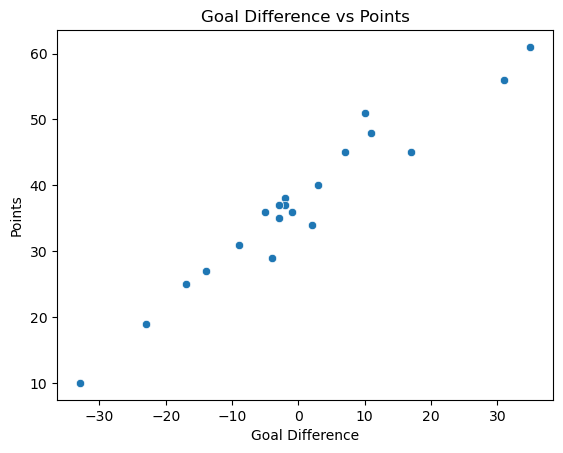

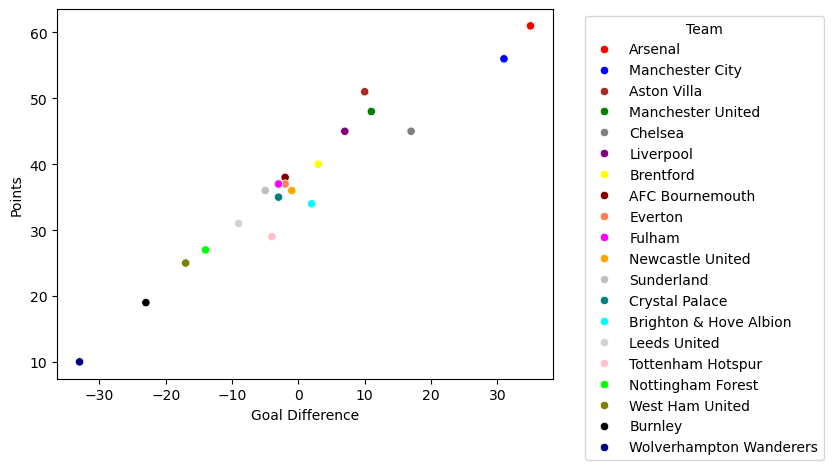

In [ ]:
sns.scatterplot(x='Goal Difference', y='Points', data=df)
plt.title('Goal Difference vs Points')
plt.xlabel('Goal Difference')
plt.ylabel('Points')
plt.show()

#Make Arsenal's point total red to highlight it
sns.scatterplot(x='Goal Difference', y='Points', data=df, hue='Team',
                palette={
                    'Arsenal': 'red',
                    'Manchester City': 'blue',
                    'Manchester United': 'green',
                    'Newcastle United': 'orange',
                    'Liverpool': 'purple',
                    'Brighton & Hove Albion': 'cyan',
                    'Fulham': 'magenta',
                    'Brentford': 'yellow',
                    'Aston Villa': 'brown',
                    'Tottenham Hotspur': 'pink',
                    'Chelsea': 'gray',
                    'West Ham United': 'olive',
                    'Crystal Palace': 'teal',
                    'Wolverhampton Wanderers': 'navy',
                    'AFC Bournemouth': 'maroon',   # match the df value
                    'Nottingham Forest': 'lime',
                    'Everton': 'coral',
                    'Leicester City': 'gold',
                    'Burnley': 'black',
                    'Sunderland': 'silver',
                    'Leeds United': 'lightgrey'
                })

#Used Copilot to help me move the legend outside of the plot area to prevent it from overlapping with the data points, making the plot clearer and easier to read.
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')

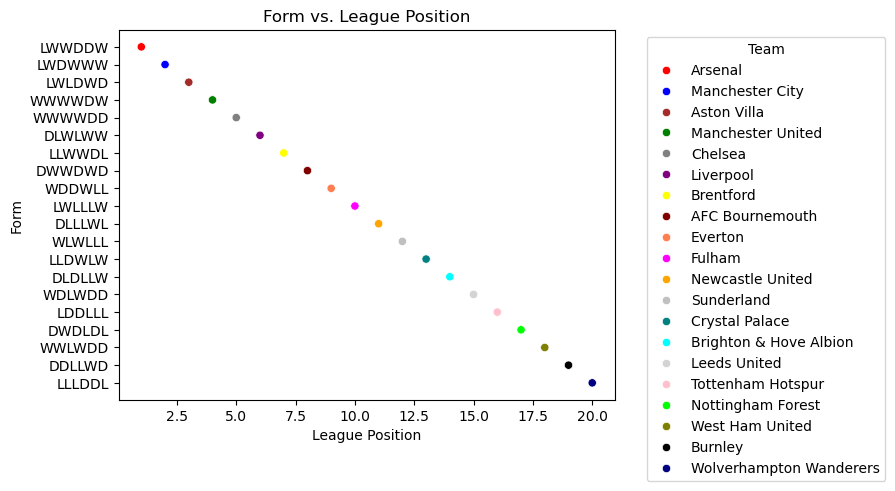

In [ ]:
#Trend Line: A "Form vs. League Position" plot to see if the current leaders are actually the ones in the best recent form
df['Position'] = df.index + 1 # create a position column from the dataframe index
sns.scatterplot(x='Position', y='Form', data=df ,hue='Team',
                palette={
                    'Arsenal': 'red',
                    'Manchester City': 'blue',
                    'Manchester United': 'green',
                    'Newcastle United': 'orange',
                    'Liverpool': 'purple',
                    'Brighton & Hove Albion': 'cyan',
                    'Fulham': 'magenta',
                    'Brentford': 'yellow',
                    'Aston Villa': 'brown',
                    'Tottenham Hotspur': 'pink',
                    'Chelsea': 'gray',
                    'West Ham United': 'olive',
                    'Crystal Palace': 'teal',
                    'Wolverhampton Wanderers': 'navy',
                    'AFC Bournemouth': 'maroon',   # match the df value
                    'Nottingham Forest': 'lime',
                    'Everton': 'coral',
                    'Leicester City': 'gold',
                    'Burnley': 'black',
                    'Sunderland': 'silver',
                    'Leeds United': 'lightgrey'
                })

#Used Copilot to help me move the legend outside of the plot area to prevent it from overlapping with the data points, making the plot clearer and easier to read.
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Form vs. League Position')
plt.xlabel('League Position')
plt.ylabel('Form')
plt.show()

In [15]:
df.head()

,Team,Played,Won,Drawn,Lost,Goals Forward,Goals Against,Goal Difference,Points,Form,Pyth,Position
0,Arsenal,28,18,7,3,56,21,35,61,LWWDDW,0.876712,1
1,Manchester City,27,17,5,5,56,25,31,56,LWDWWW,0.833821,2
2,Aston Villa,27,15,6,6,38,28,10,51,LWLDWD,0.648115,3
3,Manchester United,27,13,9,5,48,37,11,48,WWWWDW,0.627280,4
4,Chelsea,27,12,9,6,48,31,17,45,WWWWDD,0.705666,5



# Reflection:
**The metrics that stand out the most are goals forward and goal difference as well. These metrics are "Goals Forward and Goals Against. They're extremely detrimental to the team's performance through the lapse of a season.**